In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
import requests
import os

def download_data(url ,filename):
    os.makedirs("data", exist_ok=True)
    filepath = os.path.join("data", filename)
    response = requests.get(url)
    if response.status_code == 200:
        with open(filepath, 'wb') as file:
            file.write(response.content)
        print("Data downloaded and saved successfully.")
    else:
        print("Failed to download data.")

In [26]:
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [27]:
download_data(path, 'laptop_pricing_dataset_mod2.csv')

Data downloaded and saved successfully.


In [28]:
file_name="data/laptop_pricing_dataset_mod2.csv"

In [29]:
df = pd.read_csv(file_name)
df

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,233,233,Lenovo,4,2,1,7,14.0,0.896552,8,256,3.74850,1891,Medium,0,1
234,234,234,Toshiba,3,2,1,5,13.3,0.827586,8,256,2.64600,1950,Medium,1,0
235,235,235,Lenovo,4,2,1,5,12.0,0.896552,8,256,2.99880,2236,Medium,0,1
236,236,236,Lenovo,3,3,1,5,15.6,0.862069,6,256,5.29200,883,Low,1,0


In [30]:
print("First 5 rows of the DataFrame:")
print(df.head(5))

First 5 rows of the DataFrame:
   Unnamed: 0.1  Unnamed: 0  ... Screen-Full_HD  Screen-IPS_panel
0             0           0  ...              0                 1
1             1           1  ...              1                 0
2             2           2  ...              1                 0
3             3           3  ...              0                 1
4             4           4  ...              1                 0

[5 rows x 16 columns]


# Single Linear Regression

You have learnt that "CPU_frequency" is the parameter with the lowest p-value among the different features of the dataset. Create a single feature Linear Regression model that fits the pair of "CPU_frequency" and "Price" to find the model for prediction.


In [31]:
lm = LinearRegression()
X = df[["CPU_frequency"]]
y = df["Price"]
lm.fit(X, y)
Yhat = lm.predict(X)

print("Intercept of the linear regression model:", lm.intercept_)
print("Coefficient of the linear regression model:", lm.coef_)

Intercept of the linear regression model: 253.6611706858214
Coefficient of the linear regression model: [1485.19362648]


/var/folders/9c/gn50wmw50fg_5r981g9zw_740000gn/T/ipykernel_10075/2189665550.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
/var/folders/9c/gn50wmw50fg_5r981g9zw_740000gn/T/ipykernel_10075/2189665550.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147

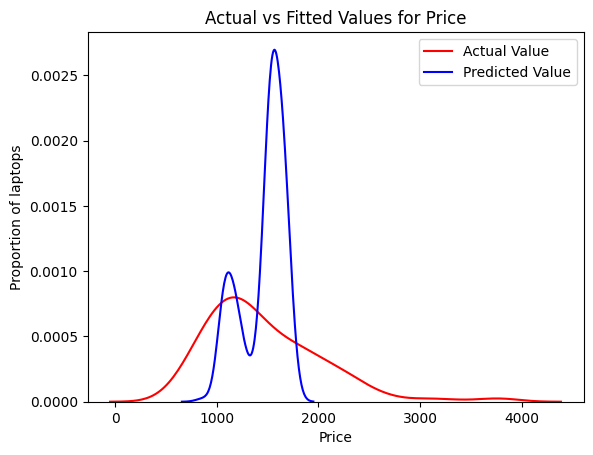

In [32]:
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")

# Create a distribution plot for predicted values
sns.distplot(Yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()



In [33]:
mse =mean_squared_error(y, Yhat)
r2 = r2_score(y, Yhat)

print("Mean Squared Error:", mse)
print("R-squared Value:", r2)


Mean Squared Error: 284583.4405868629
R-squared Value: 0.1344436321024326


# Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category'. Use all these variables to create a Multiple Linear Regression system. 


In [34]:
lm  = LinearRegression()
X   = df[["CPU_frequency", "RAM_GB", "Storage_GB_SSD", "CPU_core", "OS", "GPU", "Category"]]
y   = df["Price"]
lm.fit(X,y)
Yhat = lm.predict(X)
print("Intercept of the linear regression model:", lm.intercept_)
print("Coefficient of the linear regression model:", lm.coef_)

Intercept of the linear regression model: -841.9913259091206
Coefficient of the linear regression model: [ 9.61283977e+02  8.68089292e+01  3.94604825e-01  6.56633979e+01
 -4.27445318e+02  9.78000871e+01  1.91295466e+02]


/var/folders/9c/gn50wmw50fg_5r981g9zw_740000gn/T/ipykernel_10075/2189665550.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
/var/folders/9c/gn50wmw50fg_5r981g9zw_740000gn/T/ipykernel_10075/2189665550.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147

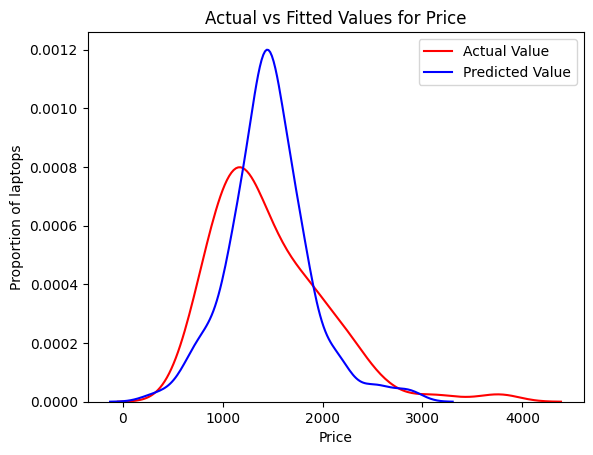

In [35]:
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")

# Create a distribution plot for predicted values
sns.distplot(Yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()



In [36]:
mse =mean_squared_error(y, Yhat)
r2 = r2_score(y, Yhat)

print("Mean Squared Error:", mse)
print("R-squared Value:", r2)


Mean Squared Error: 161680.57263893107
R-squared Value: 0.5082509055187374


# Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Remember that polynomial fits are done using `numpy.polyfit`. 


In [37]:
lm = LinearRegression()
X = df[["CPU_frequency"]]
y = df["Price"]

X = X.to_numpy().flatten()

f1 = np.polyfit(X, y, deg=1)
p1 = np.poly1d(f1)

f3 = np.polyfit(X, y, deg=3)
p3 = np.poly1d(f3)

f5 = np.polyfit(X, y, deg=5)
p5 = np.poly1d(f5)


In [38]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')

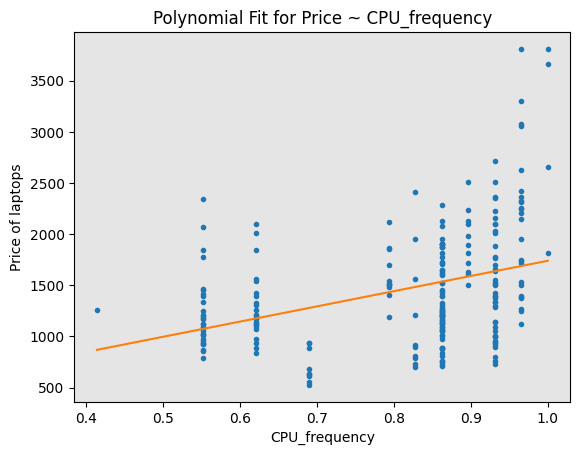

In [40]:
PlotPolly(p1, X, y, 'CPU_frequency')

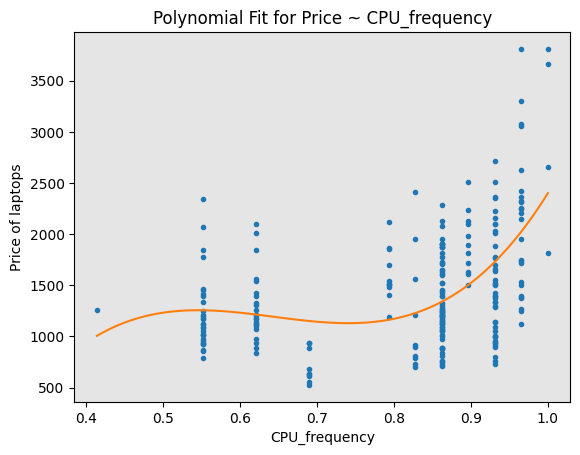

In [41]:
PlotPolly(p3, X, y, 'CPU_frequency')

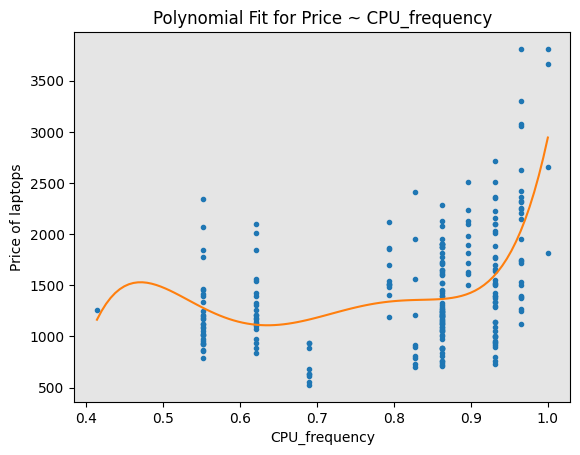

In [42]:
PlotPolly(p5, X, y, 'CPU_frequency')

In [45]:
r_squared_1 = r2_score(y, p1(X))
print('The R-square value for 1st degree polynomial is: ', r_squared_1)
print('The MSE value for 1st degree polynomial is: ', mean_squared_error(y,p1(X)))
r_squared_3 = r2_score(y, p3(X))
print('The R-square value for 3rd degree polynomial is: ', r_squared_3)
print('The MSE value for 3rd degree polynomial is: ', mean_squared_error(y,p3(X)))
r_squared_5 = r2_score(y, p5(X))
print('The R-square value for 5th degree polynomial is: ', r_squared_5)
print('The MSE value for 5th degree polynomial is: ', mean_squared_error(y,p5(X)))



The R-square value for 1st degree polynomial is:  0.1344436321024326
The MSE value for 1st degree polynomial is:  284583.4405868629
The R-square value for 3rd degree polynomial is:  0.26692640796531153
The MSE value for 3rd degree polynomial is:  241024.86303848756
The R-square value for 5th degree polynomial is:  0.30308227064437754
The MSE value for 5th degree polynomial is:  229137.29548053915


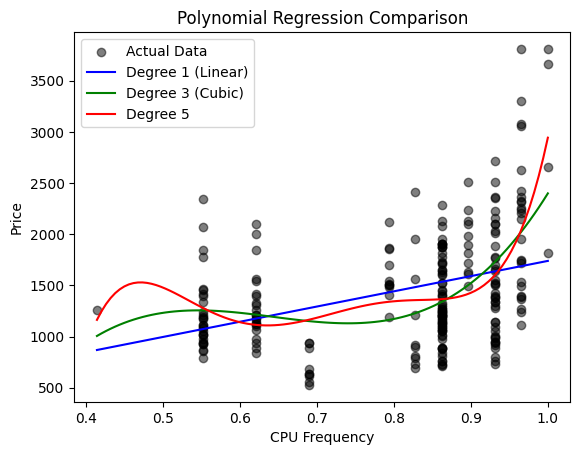

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate a smooth line of X values for plotting the curves smoothly
X_line = np.linspace(X.min(), X.max(), 100)

# 2. Plot the original data points
plt.scatter(X, y, color="black", label="Actual Data", alpha=0.5)

# 3. Plot the polynomial fits
plt.plot(X_line, p1(X_line), label="Degree 1 (Linear)", color="blue")
plt.plot(X_line, p3(X_line), label="Degree 3 (Cubic)", color="green")
plt.plot(X_line, p5(X_line), label="Degree 5", color="red")

plt.xlabel("CPU Frequency")
plt.ylabel("Price")
plt.title("Polynomial Regression Comparison")
plt.legend()
plt.show()

#  Pipeline
Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features as before to create this pipeline. 


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1. Define your target and features (Ensure X is a 2D DataFrame/array for the pipeline)
y = df["Price"]
X = df[["CPU_frequency"]].astype(float)  # Convert to float here

# 2. Set up the pipeline steps
Input = [
    ("scale", StandardScaler()),
    ("Polynomial", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression()),
]

pipe = Pipeline(Input)

# 3. Train the pipeline and make predictions using X
pipe.fit(X, y)
ypipe = pipe.predict(X)

In [54]:
mse = mean_squared_error(y, ypipe)
r_squared = r2_score(y, ypipe)
print('MSE for pipeline:', mse)
print('R^2 for pipeline:', r_squared)

MSE for pipeline: 249022.6659675117
R^2 for pipeline: 0.24260120745423774
